<a href="https://colab.research.google.com/github/1-brain-cell/python-dga/blob/master/day_4/afternoon_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DGA306 Day 4 Workshop Materials: Machine Learning for Data Analysis (Afternoon)

Lead Instructor: <code>Sirasit Lochanachit</code>

# Classification: คุณภาพน้ำแหล่งน้ำผิวดิน (WQI)



## ชุดข้อมูล: ดัชนีคุณภาพน้ำแหล่งน้ำผิวดิน (WQI)

จังหวัดสระบุรี

- reference data [here](https://gdcatalog.go.th/dataset/gdpublish-dataset_10_1118)

ชุดข้อมูลที่ใช้ในการเรียนรอบนี้ ปรับปรุงและทำความสะอาดมาจากข้อมูลจริงใน reference โดยอ้างอิงการสร้าง label จาก [เกณฑ์](https://www.pcd.go.th/waters/%E0%B8%94%E0%B8%B1%E0%B8%8A%E0%B8%99%E0%B8%B5%E0%B8%84%E0%B8%B8%E0%B8%93%E0%B8%A0%E0%B8%B2%E0%B8%9E%E0%B8%99%E0%B9%89%E0%B8%B3%E0%B9%81%E0%B8%AB%E0%B8%A5%E0%B9%88%E0%B8%87%E0%B8%99%E0%B9%89%E0%B8%B3%E0%B8%9C%E0%B8%B4%E0%B8%A7%E0%B8%94%E0%B8%B4%E0%B8%99-water-quality-indexwqi/)

**ขนาด:** ~98 แถว (สถานีตรวจวัด × ไตรมาส)

**โจทย์ของเรา:** ทำนายว่าแหล่งน้ำ **ผ่าน** หรือ **ไม่ผ่าน** มาตรฐาน (WQI ≥ 61)

| Column | ประเภทของข้อมูล | ความหมาย | หน่วย |
|--------|-----------------|-----------|-------|
| DO | Continuous | Dissolved Oxygen (ออกซิเจนละลายน้ำ) | mg/L |
| BOD | Continuous | BOD : Biochemical Oxygen Demand (ความต้องการออกซิเจนทางชีวเคมี) | mg/L |
| NH3 | Continuous | Ammonia Nitrogen (แอมโมเนียไนโตรเจน) | mg/L |
| target_binary | Binary | ผ่าน / ไม่ผ่าน | label |

เราจะใช้ค่า StandardScaler เพราะ Feature ทั้ง 3 อยู่คนละ scale

# Step 1: Import Libraries

In [1]:
# นำเข้า library หลัก
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
)

import matplotlib as mpl
import matplotlib.pyplot as plt
import urllib.request
import os

font_url = "https://github.com/google/fonts/raw/main/ofl/sarabun/Sarabun-Regular.ttf"
font_path = "Sarabun-Regular.ttf"

if not os.path.exists(font_path):
    urllib.request.urlretrieve(font_url, font_path)

mpl.font_manager.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'Sarabun'

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Step 2: Data Exploration

⭐ โหลดข้อมูลและตรวจสอบข้อมูลเบื้องต้น

In [2]:
df = pd.read_csv("wqi.csv", encoding="utf-8-sig")
df.head()

,ปี,ไตรมาส,แหล่งน้ำ,จุดตรวจวัด,BOD,DO,FCB,NH3,NO3,TCB,WQI,ระดับ,target_binary,target_multi
0,2560,1,แม่น้ำป่าสัก,PS04,3.9,3.2,4600.0,0.07,0.33,14000,60,เสื่อมโทรม,ไม่ผ่าน,เสื่อมโทรม
1,2560,1,แม่น้ำป่าสัก,PS05,2.3,5.0,490.0,0.02,0.35,2400,64,พอใช้,ผ่าน,พอใช้
2,2560,1,แม่น้ำป่าสัก,PS07,1.8,4.0,5400.0,0.01,0.37,16000,60,เสื่อมโทรม,ไม่ผ่าน,เสื่อมโทรม
3,2560,2,แม่น้ำป่าสัก,PS04,3.5,6.0,1400.0,0.11,0.33,16000,56,เสื่อมโทรม,ไม่ผ่าน,เสื่อมโทรม
4,2560,2,แม่น้ำป่าสัก,PS05,2.6,7.8,490.0,0.02,0.15,790,70,พอใช้,ผ่าน,พอใช้


In [3]:
df.shape

(98, 14)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ปี             98 non-null     int64  
 1   ไตรมาส         98 non-null     int64  
 2   แหล่งน้ำ       98 non-null     object 
 3   จุดตรวจวัด     98 non-null     object 
 4   BOD            98 non-null     float64
 5   DO             98 non-null     float64
 6   FCB            97 non-null     float64
 7   NH3            98 non-null     float64
 8   NO3            94 non-null     float64
 9   TCB            98 non-null     int64  
 10  WQI            98 non-null     int64  
 11  ระดับ          98 non-null     object 
 12  target_binary  98 non-null     object 
 13  target_multi   98 non-null     object 
dtypes: float64(5), int64(4), object(5)
memory usage: 10.8+ KB


In [5]:
# ตรวจสอบข้อมูลสถิติพื้นฐาน
df.describe()

,ปี,ไตรมาส,BOD,DO,FCB,NH3,NO3,TCB,WQI
count,98.000000,98.00000,98.000000,98.000000,97.000000,98.000000,94.000000,98.000000,98.000000
mean,2562.683673,2.44898,2.173469,5.915306,2053.515464,0.104388,0.336489,7496.214286,67.132653
std,1.808325,1.14083,1.066215,1.601118,3134.825627,0.103057,0.365074,17030.563252,11.133342
min,2560.000000,1.00000,1.000000,2.400000,20.000000,0.010000,0.010000,20.000000,47.000000
25%,2561.000000,1.00000,1.400000,4.925000,330.000000,0.042500,0.062500,790.000000,58.000000
50%,2563.000000,2.00000,1.800000,5.800000,790.000000,0.070000,0.250000,3500.000000,65.500000
75%,2564.000000,3.00000,2.700000,6.800000,2600.000000,0.125000,0.437500,9200.000000,71.500000
max,2566.000000,4.00000,7.300000,12.000000,22000.000000,0.560000,1.760000,160000.000000,91.000000




---



In [6]:
# ตรวจสอบค่าว่างในแต่ละคอลัมน์
df.isnull().sum()

,0
ปี,0
ไตรมาส,0
แหล่งน้ำ,0
จุดตรวจวัด,0
BOD,0
DO,0
FCB,1
NH3,0
NO3,4
TCB,0




---



⭐ ตรวจสอบว่าแต่ละ class มีจำนวนเท่าใด

In [7]:
# ดูความสมดุลของ class ผ่าน/ไม่ผ่าน
df['target_binary'].value_counts()

,count
target_binary,
ผ่าน,65
ไม่ผ่าน,33


# Step 3: Data Analysis & Visualization

การทำ Data Analysis และ Data Visualization เป็นอีกขั้นตอนที่สำคัญ เนื่องจากขั้นตอนนี้ช่วยให้เห็นลักษณะของข้อมูล และทำความเข้าใจข้อมูลได้ดีขึ้น

⭐ เพื่อให้การวิเคราะห์ข้อมูลเป็นไปอย่างถูกต้อง และเหมาะสม เราจะแบ่งประเภทข้อมูลออกเป็น 2 ประเภท คือ



```
1. Numerical คือ ข้อมูลตัวเลข (เชิงปริมาณ)
2. Categorical คือ ข้อมูลหมวดหมู่ (เชิงคุณภาพ)
```


## 1. Numerical

- ข้อมูล Numerical เป็นข้อมูลที่สามารถ + - x ÷ ได้
- สามารถดูค่าเฉลี่ย (mean), ค่าสูงสุด (max), ค่าต่ำสุด (min) ได้
- สามารถสร้างกราฟ Histogram, คำนวณ Correlation หรือใช้กับสูตรทางคณิตศาสตร์ได้



---


> ในที่นี้ Feature ที่เราจะใช้ทำนายคือ DO, BOD, NH3 ซึ่งเป็นข้อมูล Numerical ทั้งหมด



In [8]:
numerical = ['DO', 'BOD', 'NH3']

In [9]:
numerical

['DO', 'BOD', 'NH3']

**📊 Distribution of all Numerical Data**

สร้าง Histogram ของข้อมูลทั้ง 2 กลุ่มแบ่งตาม Class
- สีแดงคือ ไม่ผ่าน
- สีฟ้าคือ ผ่าน

In [10]:
classes = df['target_binary'].unique()
classes

array(['ไม่ผ่าน', 'ผ่าน'], dtype=object)

In [11]:
color_map = {classes[0]:'tomato', classes[1]:'steelblue'}

In [12]:
color_map

{'ไม่ผ่าน': 'tomato', 'ผ่าน': 'steelblue'}

ใช้ Loop ในการสร้าง Histogram ของแต่ละตัวแปรใน `numerical`

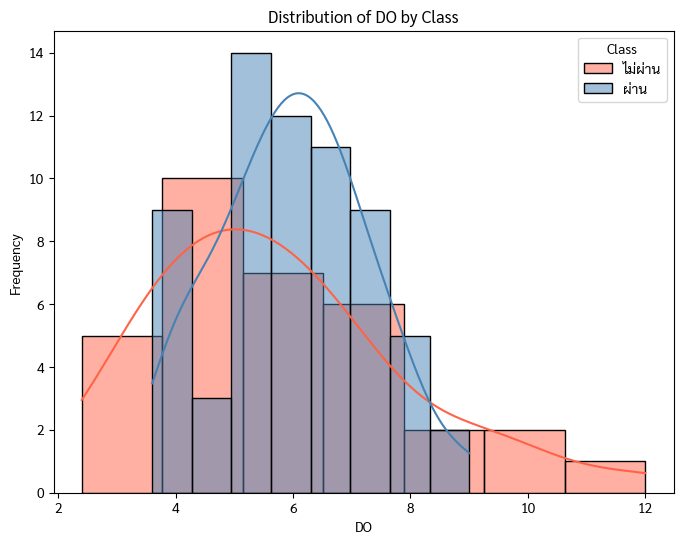

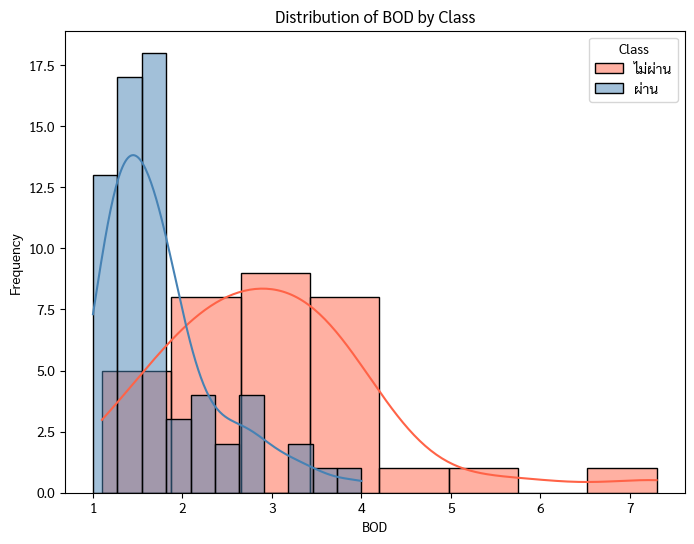

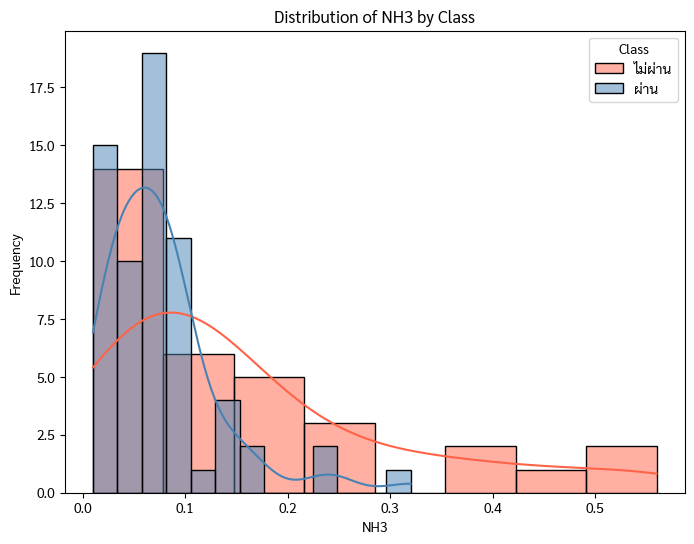

In [13]:
for col in numerical:
    plt.figure(figsize=(8, 6))
    for cls in classes:
        sns.histplot(data=df[df['target_binary'] == cls],
                     x=col, kde=True, color=color_map[cls], label=cls)
    plt.title(f'Distribution of {col} by Class')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.legend(title='Class')
    plt.show()
    print('\n')

- เนื่องจาก Histogram บางตัวแปรอาจค่อนข้างมองภาพได้ยาก เราจึงสามารถใช้ **KDE plot** (Kernel Density Estimate) ที่แสดงความหนาแน่น (density) ซึ่งแสดงถึงการกระจายตัวของข้อมูลเช่นกันในลักษณะ function ของข้อมูล เพื่อทำให้เห็นข้อมูลส่วนนี้ง่ายขึ้น

> **KDE Plot** เป็นเส้นโค้งเรียบ (smooth curve) ที่ประมาณการกระจายตัวของข้อมูล
> ช่วยให้เห็นรูปร่างของการกระจายชัดเจนกว่า Histogram โดยเฉพาะเมื่อข้อมูลมีจำนวนน้อย

**📈 KDE Plot ของแต่ละ Feature แบ่งตาม Class**

- สีแดงคือ ไม่ผ่าน
- สีฟ้าคือ ผ่าน

> ถ้าเส้นของ 2 class แยกกันชัด แปลว่า Feature นั้นช่วยแยก class ได้ดี
> ถ้าเส้นทับกันมาก แปลว่า Feature นั้นแยก class ได้ไม่ดีนัก

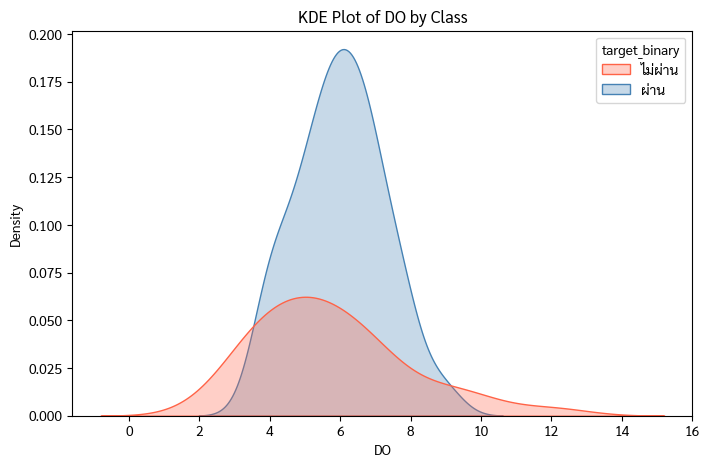

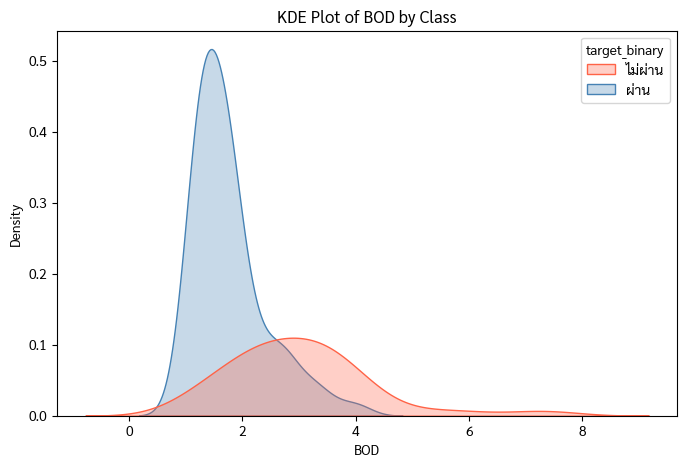

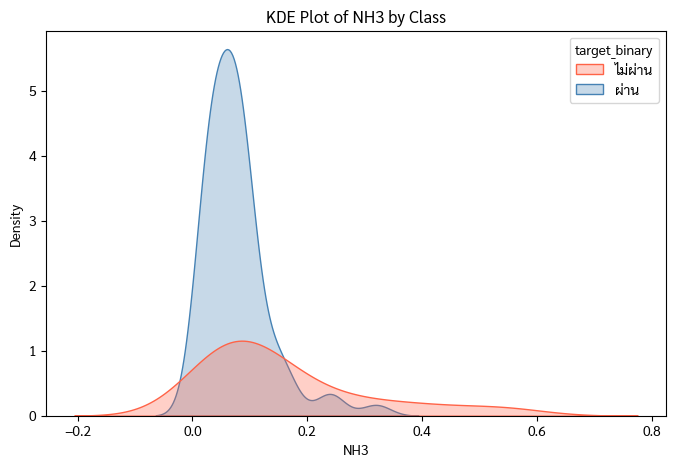

In [14]:
# KDE Plot สำหรับทุก Feature แบ่งตาม Class
for col in numerical:
    plt.figure(figsize=(8, 5))
    sns.kdeplot(data=df, x=col, hue='target_binary',
                palette=color_map, fill=True, alpha=0.3)
    plt.title(f'KDE Plot of {col} by Class')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.show()
    print('\n')

**สรุปจาก Distribution & KDE Plot:**

| Feature | การแยก Class | สังเกต |
|---------|-------------|--------|
| **DO** | ดี | ค่า DO สูง → น้ำมีโอกาสผ่านมาตรฐานมากขึ้น |
| **BOD** | ปานกลาง | ค่า BOD สูง → น้ำมีโอกาสไม่ผ่านมากขึ้น |
| **NH3** | ปานกลาง | ค่า NH3 ต่ำ → น้ำมีคุณภาพดีกว่า |

> จุดที่เส้น KDE ทับกัน (overlap) คือบริเวณที่โมเดลจะตัดสินใจยากที่สุด

## 2. Categorical

- ข้อมูลที่ไม่สามารถวัดค่าออกมาเป็นตัวเลขได้โดยตรง
- ข้อมูลประเภทนี้จะบอกถึงลักษณะหรือประเภทของสิ่งของต่างๆ
- สามารถแทนข้อมูลดังกล่าวด้วยตัวเลขหรือข้อความ แต่ตัวเลขที่แทนไม่มีความหมายในเชิงคณิตศาสตร์

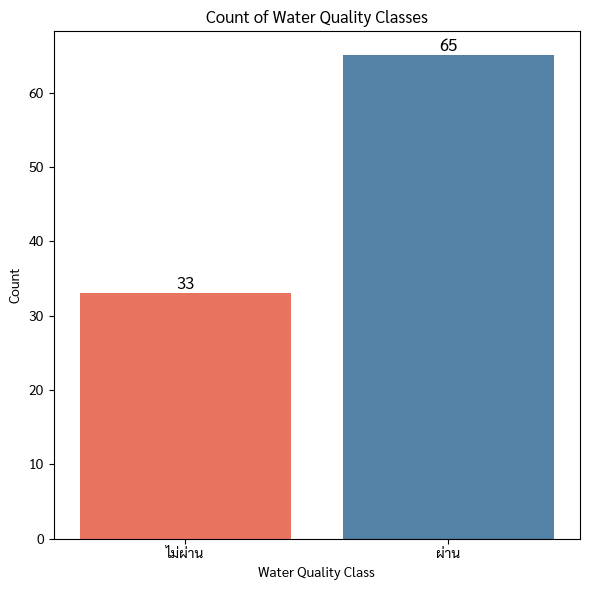

In [15]:
plt.figure(figsize=(6, 6))
ax = sns.countplot(x='target_binary', data=df, palette=['tomato', 'steelblue'])
for container in ax.containers:
    ax.bar_label(container, fontsize=12)
ax.set(xlabel='Water Quality Class', ylabel='Count', title='Count of Water Quality Classes')
plt.tight_layout()

## Grouped Mean Comparison

⭐ ดูค่าเฉลี่ยของแต่ละ Feature ว่าแตกต่างกันอย่างไรในแต่ละ class

In [16]:
groupbyclass = df.groupby('target_binary')[numerical].mean().transpose()
groupbyclass

target_binary,ผ่าน,ไม่ผ่าน
DO,5.998462,5.751515
BOD,1.753846,3.000000
NH3,0.076308,0.159697


## Correlation

> ค่าสหสัมพันธ์ (Correlation) : ค่าที่วัดความสัมพันธ์ระหว่าง 2 ตัวแปร ว่าสัมพันธ์กันมากน้อยขนาดไหน

Correlation ต้องใช้กับข้อมูลตัวเลข อย่างในกรณีนี้ จะเป็นค่า DO, BOD, NH3 โดยมีค่าอยู่ระหว่าง -1 ถึง 1


| ค่า    | ความหมาย |
| ------ | ------ |
| **+1** | ความสัมพันธ์สูงมาก (ทิศทางเดียวกัน) |
| **0.x** | มีแนวโน้มไปทางเดียวกัน |
| **0**  | ไม่มีความสัมพันธ์เชิงเส้น |
| **-0.x** | มีแนวโน้มสวนทางกัน |
| **-1** | ความสัมพันธ์สูงมาก (ทิศทางตรงข้าม) |

In [17]:
corr_df = df[numerical].corr()

In [18]:
corr_df

,DO,BOD,NH3
DO,1.000000,0.228150,-0.180348
BOD,0.228150,1.000000,0.276439
NH3,-0.180348,0.276439,1.000000


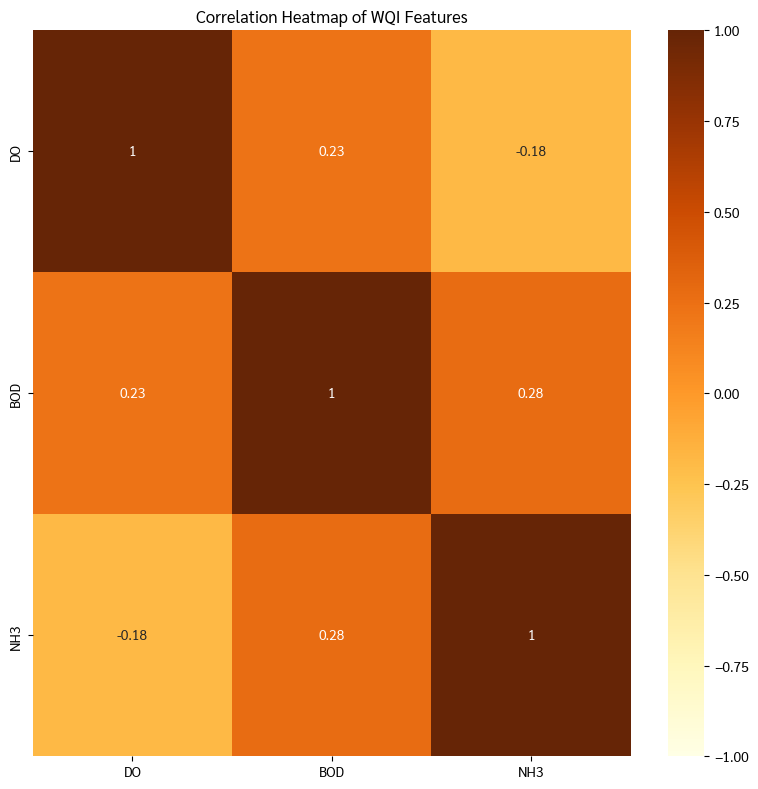

In [19]:
color_cmap = sns.color_palette('YlOrBr', as_cmap=True)

plt.figure(figsize=(8, 8))
sns.heatmap(corr_df, annot=True, cmap=color_cmap, vmin=-1, vmax=1)
plt.title('Correlation Heatmap of WQI Features')
plt.tight_layout()
plt.show()

# Step 4: Data Preprocessing

⭐ ในส่วนนี้เราจะทำการ**เตรียม**ข้อมูลเบื้องต้นให้พร้อมต่อการใช้ฝึกฝนโมเดล Machine Learning

> สร้างตัวแปร wqi ซึ่งเก็บสำเนาจากข้อมูลเดิม (df) เพื่อให้ข้อมูลเดิมไม่เสียหาย

In [20]:
wqi = df.copy()



> แบ่งข้อมูลเป็นข้อมูลที่ใช้ฝึกโมเดล(X) และเป้าหมายที่ใช้ทำนาย(y)



In [21]:
# เลือก Feature ที่จะนำมาใช้ฝึกโมเดล
X = wqi[['DO', 'BOD', 'NH3']]

In [22]:
X

,DO,BOD,NH3
0,3.2,3.9,0.07
1,5.0,2.3,0.02
2,4.0,1.8,0.01
3,6.0,3.5,0.11
4,7.8,2.6,0.02
...,...,...,...
93,5.2,2.7,0.02
94,5.8,1.3,0.07
95,5.8,1.4,0.02
96,6.4,1.2,0.02


> ในส่วนของ y ซึ่งเป็นเป้าหมายของการทำนาย เดิมเนื่องจากโมเดล Machine Learning ไม่สามารถเข้าใจตัวหนังสือได้ จึงต้องแปลงข้อความให้เป็นตัวเลขก่อน โดยอาจใช้ LabelEncoder ซึ่งเป็นเครื่องมือหนึ่งในการแปลง หรือในที่นี้ เราจะใช้วิธีการง่าย ๆ โดยการแปลง Label ด้วยเงื่อนไขที่เรากำหนดเอง

เราจะแทนตัวเลขให้คุณภาพน้ำ
- 0 คือ ไม่ผ่าน
- 1 คือ ผ่าน

In [23]:
# ถ้าเราพิมพ์คำสั่งแบบนี้ มันจะทำการเช็คข้อมูลทั้ง column
# เพื่อดูว่า ข้อมูลข้างใน ตรงกับคำว่า 'ผ่าน' มั้ย

wqi['target_binary'] == 'ผ่าน'

,target_binary
0,False
1,True
2,False
3,False
4,True
...,...
93,False
94,True
95,True
96,True


In [24]:
# หลังจากนั้น ใช้ type casting ซึ่งจะเป็นคำสั่งที่เปลี่ยนข้อมูล True/False ให้กลายเป็นตัวเลข 1/0
# True = เลข 1
# False = เลข 0

# ตัวอย่าง
(wqi['target_binary'] == 'ผ่าน').astype(int)

,target_binary
0,0
1,1
2,0
3,0
4,1
...,...
93,0
94,1
95,1
96,1


In [25]:
# เตรียม Target
y = (wqi['target_binary'] == 'ผ่าน').astype(int)

In [26]:
y

,target_binary
0,0
1,1
2,0
3,0
4,1
...,...
93,0
94,1
95,1
96,1


In [27]:
y.value_counts()

,count
target_binary,
1,65
0,33


**วิธีนี้สามารถใช้ได้กับข้อมูลที่มี 2 label เพื่อความสะดวกและรวดเร็ว**

!! **หากมี label มากกว่า 2 ควรใช้ LabelEncoder หรือการ map ข้อมูล**

> แบ่งข้อมูลออกเป็นข้อมูลฝึก 75% และข้อมูลทดสอบ 25%

- random_state = 42	เลขที่ตั้งไว้ให้สุ่มแบบเดิมทุกครั้ง

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [29]:
X_train.head()

,DO,BOD,NH3
33,7.8,1.8,0.09
9,6.0,1.8,0.03
80,8.8,4.0,0.08
11,5.0,1.1,0.07
65,6.1,2.7,0.04


In [30]:
# ลองเปลี่ยน random_state เล่นได้

# Step 5: Data Modeling

⭐ ขั้นตอนนี้เป็นการนำข้อมูลที่เราเตรียมไว้แล้วมาให้โมเดล Machine Learning เรียนรู้

🏷️ เรากำลังจะทำ Classification ซึ่งเป็นการเรียนรู้แบบมีผู้สอน (Supervised Learning) ใช้ทำนายผลลัพธ์หรือเหตุการณ์ในลักษณะที่ไม่ใช่ค่าต่อเนื่อง (discrete) เช่น การทำนายว่าน้ำผ่านหรือไม่ผ่านมาตรฐาน

## Logistic Regression

In [31]:
clf = LogisticRegression(random_state=42)

In [32]:
clf.fit(X_train, y_train)

LogisticRegression(random_state=42)

# Step 6: Evaluation

พิจารณาจากค่าที่ใช้วัดต่าง ๆ เช่น Accuracy, Precision, Recall หรือ F1-score

## Accuracy

$$\text{Accuracy} = \frac{จำนวนข้อมูลที่โมเดลทายถูกทั้งหมด}{\text{จำนวนข้อมูลทั้งหมด}}× 100$$

In [33]:
# แสดง Train และ Test Accuracy เปรียบเทียบกัน
y_pred_train = clf.predict(X_train)
y_pred = clf.predict(X_test)

print("Logistic Regression Model Results:")
print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Accuracy: ", accuracy_score(y_test, y_pred))
print("--------------------------------------------------------")

Logistic Regression Model Results:
Train Accuracy: 0.7945205479452054
Test Accuracy:  0.88
--------------------------------------------------------


แสดงผลลัพธ์ของค่าวัดต่าง ๆ ในรูปแบบตาราง

In [34]:
# Classification Report แบบ text
print(classification_report(y_test, y_pred, target_names=['ไม่ผ่าน', 'ผ่าน']))

              precision    recall  f1-score   support

     ไม่ผ่าน       0.89      0.80      0.84        10
        ผ่าน       0.88      0.93      0.90        15

    accuracy                           0.88        25
   macro avg       0.88      0.87      0.87        25
weighted avg       0.88      0.88      0.88        25



In [35]:
# Classification Report แบบ DataFrame พร้อม rename และ transpose
report_df = pd.DataFrame(
    classification_report(y_test, y_pred, output_dict=True)
)
report_df = report_df.rename(columns={'0': 'ไม่ผ่าน', '1': 'ผ่าน'})
display(report_df.transpose())

,precision,recall,f1-score,support
ไม่ผ่าน,0.888889,0.800000,0.842105,10.00
ผ่าน,0.875000,0.933333,0.903226,15.00
accuracy,0.880000,0.880000,0.880000,0.88
macro avg,0.881944,0.866667,0.872666,25.00
weighted avg,0.880556,0.880000,0.878778,25.00


## Confusion Matrix

⭐ใช้ confusion matrix ในการเปรียบเทียบว่าผลการทำนายถูกต้องเท่าใด

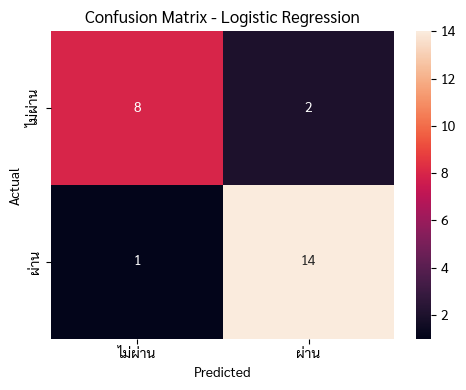

-------------------------------------------


In [36]:
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)

plt.figure(figsize=(5, 4))

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['ไม่ผ่าน', 'ผ่าน'],
            yticklabels=['ไม่ผ่าน', 'ผ่าน'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("-------------------------------------------")

# Step 7: Test Prediction on New Data

⭐ ในส่วนนี้เราจะทดลองนำโมเดลที่เราฝึกฝนแล้วไปพยากรณ์กับข้อมูลใหม่

In [37]:
col_for_new_data = ['DO', 'BOD', 'NH3']

- สุ่มสร้างข้อมูลใหม่ โดยให้ข้อมูลในแต่ละคอลัมน์อยู่ในช่วงของค่า min และค่า max ของข้อมูลเดิม จำนวน 5 ตัวอย่าง

In [38]:
min_values = wqi[col_for_new_data].min()
max_values = wqi[col_for_new_data].max()

np.random.seed(42)
n_samples = 5  # number of samples

new_wqi = pd.DataFrame({
    col: np.random.uniform(min_values[col], max_values[col], n_samples)
    for col in min_values.index
})

- เรียกดูข้อมูลใหม่

In [39]:
new_wqi

,DO,BOD,NH3
0,5.995585,1.982765,0.021321
1,11.526857,1.365927,0.543450
2,9.427142,6.456910,0.467843
3,8.147121,4.787025,0.126787
4,3.897779,5.460857,0.110004


## Logistic Regression

- ทดลองนำโมเดล Logistic Regression มาใช้ในการทำนายข้อมูลชุดใหม่



> เพื่อให้เห็นชัดเจนขึ้นว่า Logistic Regression คิดผลทำนายอย่างไร จึงแสดงผลด้วยตารางความน่าจะเป็น ที่โมเดล Logistic Regression คำนวณออกมาสำหรับข้อมูลใหม่ที่เราสร้างขึ้น



In [40]:
probabilities = clf.predict_proba(new_wqi)

probability_df = pd.DataFrame(probabilities, columns=['ไม่ผ่าน (0)', 'ผ่าน (1)'])



> ตารางแสดงความน่าจะเป็นที่โมเดล Logistic Regression คิดคำนวณออกมา
- แต่ละแถว = ข้อมูลน้ำตัวอย่างใหม่ 1 ตัวอย่าง
- โมเดลจะให้ค่าร้อยละ (เช่น 0.81 = 81%) สำหรับแต่ละ class
- ค่าที่มากที่สุดจะเป็น class ที่โมเดลใช้ในการทำนายผลออกมา



In [41]:
probability_df

,ไม่ผ่าน (0),ผ่าน (1)
0,0.239385,0.760615
1,0.032762,0.967238
2,0.976093,0.023907
3,0.855241,0.144759
4,0.982019,0.017981


In [42]:
prediction = clf.predict(new_wqi)

In [43]:
# ผลทำนายจากโมเดล Logistic Regression
# 0 : ไม่ผ่าน
# 1 : ผ่าน
prediction

array([1, 1, 0, 0, 0])

**กราฟแสดงความน่าจะเป็นที่โมเดลทำนายสำหรับข้อมูลใหม่**

- แต่ละแท่งแทนข้อมูลน้ำตัวอย่างใหม่ 1 ตัวอย่าง
- ตัวเลขบนแท่งคือร้อยละของความน่าจะเป็นที่โมเดลคำนวณ

> สีที่กินพื้นที่มาก = โมเดลคำนวณความน่าจะเป็นว่าจะเป็น class นั้นมาก



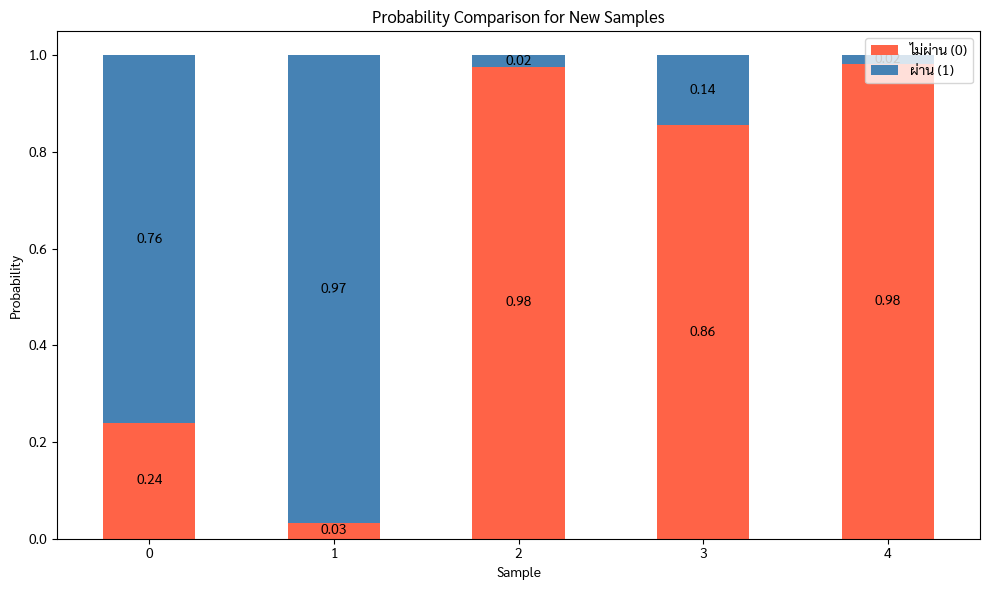

In [44]:
plt.figure(figsize=(10, 6))

ax = plt.gca()

probability_df.plot(kind='bar', stacked=True, ax=ax, color=['tomato', 'steelblue'])

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='center')

plt.title('Probability Comparison for New Samples')
plt.xlabel('Sample')
plt.ylabel('Probability')
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

---

# Bonus: Decision Tree

- ทดลองนำโมเดล Decision tree มาใช้ในการทำนายข้อมูลชุดใหม่

In [45]:
dt_clf = DecisionTreeClassifier(random_state=42)

In [46]:
dt_clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [47]:
# Evaluate Decision Tree
y_pred_dt = dt_clf.predict(X_test)
print("Decision Tree : Train Accuracy:", accuracy_score(y_train, dt_clf.predict(X_train)))
print("Decision Tree : Test Accuracy: ", accuracy_score(y_test, y_pred_dt))

Decision Tree : Train Accuracy: 1.0
Decision Tree : Test Accuracy:  0.6


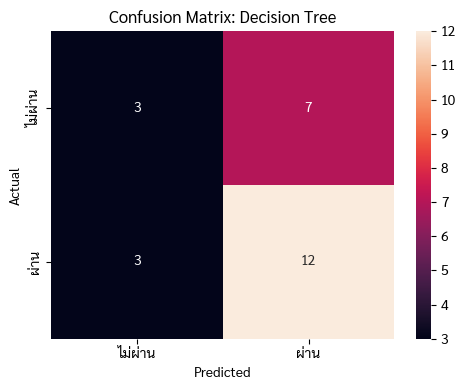

In [48]:
# Confusion Matrix ของ Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_dt, annot=True, fmt='d',
            xticklabels=['ไม่ผ่าน', 'ผ่าน'],
            yticklabels=['ไม่ผ่าน', 'ผ่าน'])
plt.title('Confusion Matrix: Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

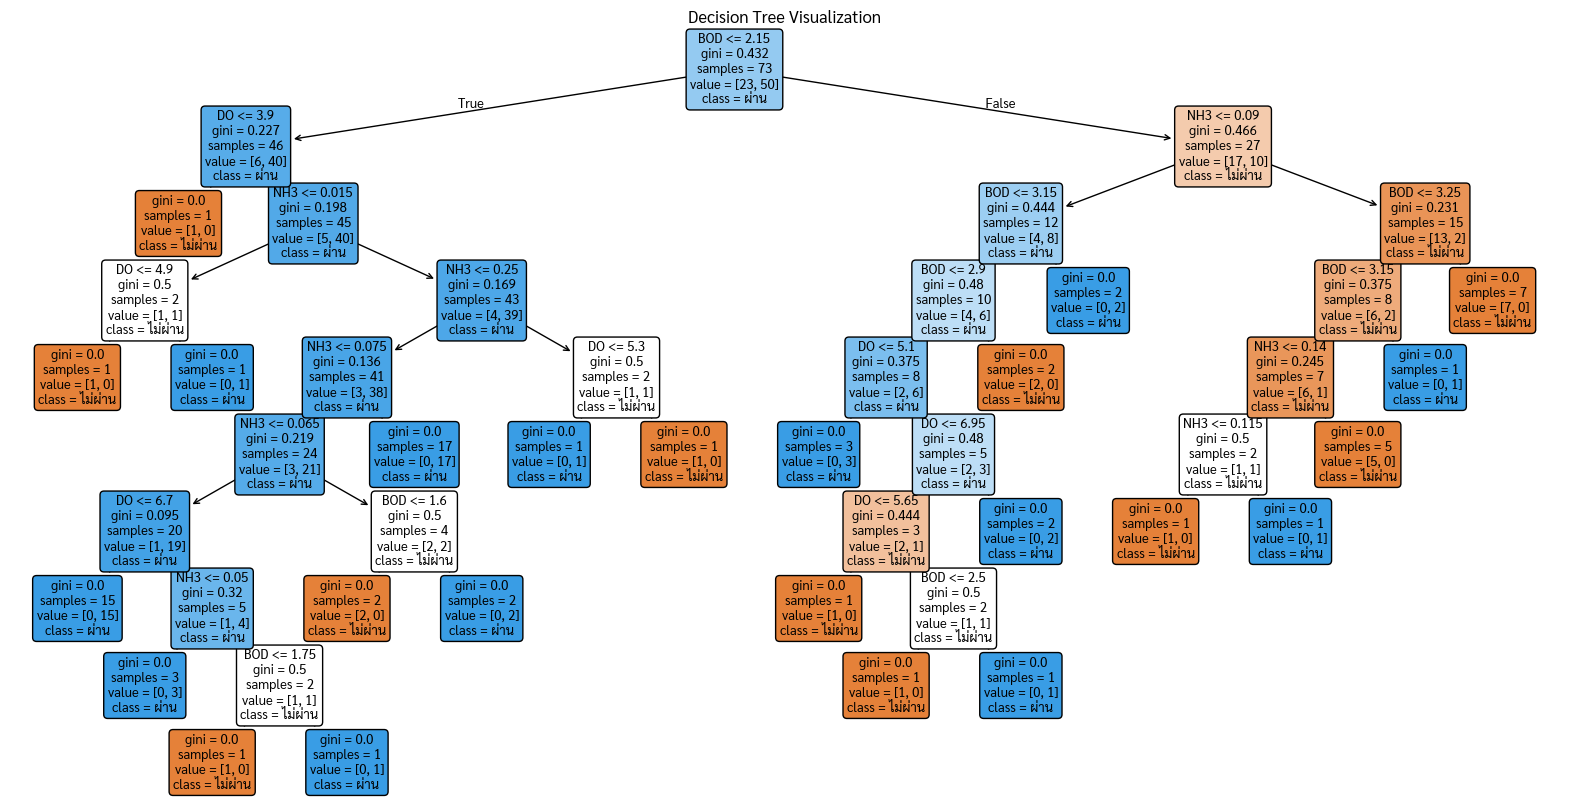

In [49]:
# Visualization

plt.figure(figsize=(20, 10))
plot_tree(dt_clf, filled=True, feature_names=X.columns, class_names=['ไม่ผ่าน', 'ผ่าน'], rounded=True)
plt.title('Decision Tree Visualization')
plt.show()

In [50]:
# ทำนาย new data ด้วย Decision Tree เพื่อเปรียบเทียบกับ Logistic Regression
new_pred_dt = dt_clf.predict(new_wqi)
print("Logistic Regression prediction:", prediction)
print("Decision Tree prediction:      ", new_pred_dt)

Logistic Regression prediction: [1 1 0 0 0]
Decision Tree prediction:       [1 0 0 0 0]


---

# Challenges

1. ทดลองใช้ Model Classification อื่น ๆ ในการ Train Model
2. เปรียบเทียบ Accuracy, precision, recall, f1-score ระหว่าง
    - Logistic Regression
    - Decision Tree
    - Random Forest
3. สร้าง confusion matrix ของแต่ละ Model
4. สร้างกราฟเปรียบเทียบ metric ระหว่าง Model

## 1. Evaluation with Other Models

In [51]:
# define the Models
ClassificationModels = {
    'Logistic Regression' : LogisticRegression() ,
    'Random Forest' : RandomForestClassifier() ,
    'Descion Tree': DecisionTreeClassifier()
}

In [52]:
# Train the models
for name, model in ClassificationModels.items():
    model.fit(X_train, y_train)
    print(f"*{name}* model has been trained successfully.")

*Logistic Regression* model has been trained successfully.
*Random Forest* model has been trained successfully.
*Descion Tree* model has been trained successfully.


## 2. Compare Error Metrics between Models

⭐ หลังจากที่เราให้โมเดล Machine Learning เรียนรู้ไปแล้ว เราจึงต้องมีการทดสอบด้วยชุดข้อมูลทดสอบ และพิจารณาจากค่าที่ใช้วัดต่าง ๆ เช่น Accuracy, Precision, Recall หรือ F1-score



`(ขึ้นกับบริบทและเป้าหมายของงานด้วย)`



In [53]:
models_evaluate = pd.DataFrame()
for name, model in ClassificationModels.items():

    pred_test = model.predict(X_test)

    model_evaluate = {
        'Accuracy': accuracy_score(y_true=y_test, y_pred=pred_test),
        'Precision': precision_score(y_true=y_test, y_pred=pred_test),
        'Recall': recall_score(y_true=y_test, y_pred=pred_test),
        'F1-score': f1_score(y_true=y_test, y_pred=pred_test)
    }

    # อีกแบบ
    # model_evaluate = {
    # metric.__name__: metric(y_test, pred_test)
    # for metric in [accuracy_score, precision_score, recall_score, f1_score]
    # }

    model_evaluate = pd.DataFrame(model_evaluate,index=[f'{name}'])
    models_evaluate = pd.concat([models_evaluate, model_evaluate])

models_evaluate

,Accuracy,Precision,Recall,F1-score
Logistic Regression,0.88,0.875000,0.933333,0.903226
Random Forest,0.80,0.777778,0.933333,0.848485
Descion Tree,0.60,0.631579,0.800000,0.705882


In [54]:
# Evaluate the models
for name, model in ClassificationModels.items():
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    print(name)
    print("Train Accuracy Score:", accuracy_score(y_train, pred_train))
    print("Test Accuracy Score" , accuracy_score(y_test, pred_test))

    report = pd.DataFrame(classification_report(y_test, pred_test, output_dict=True))
    report = report.rename(columns={'0':'ไม่ผ่าน', '1':'ผ่าน'})
    display(report.transpose())
    print("--------------------------------------------------------")

Logistic Regression
Train Accuracy Score: 0.7945205479452054
Test Accuracy Score 0.88


,precision,recall,f1-score,support
ไม่ผ่าน,0.888889,0.800000,0.842105,10.00
ผ่าน,0.875000,0.933333,0.903226,15.00
accuracy,0.880000,0.880000,0.880000,0.88
macro avg,0.881944,0.866667,0.872666,25.00
weighted avg,0.880556,0.880000,0.878778,25.00


--------------------------------------------------------
Random Forest
Train Accuracy Score: 1.0
Test Accuracy Score 0.8


,precision,recall,f1-score,support
ไม่ผ่าน,0.857143,0.600000,0.705882,10.0
ผ่าน,0.777778,0.933333,0.848485,15.0
accuracy,0.800000,0.800000,0.800000,0.8
macro avg,0.817460,0.766667,0.777184,25.0
weighted avg,0.809524,0.800000,0.791444,25.0


--------------------------------------------------------
Descion Tree
Train Accuracy Score: 1.0
Test Accuracy Score 0.6


,precision,recall,f1-score,support
ไม่ผ่าน,0.500000,0.30,0.375000,10.0
ผ่าน,0.631579,0.80,0.705882,15.0
accuracy,0.600000,0.60,0.600000,0.6
macro avg,0.565789,0.55,0.540441,25.0
weighted avg,0.578947,0.60,0.573529,25.0


--------------------------------------------------------


## 3. Confusion Matrix


 Logistic Regression :



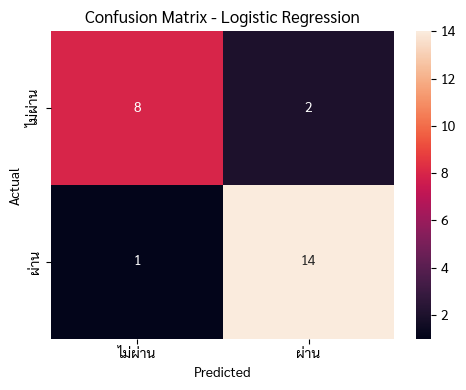


 Random Forest :



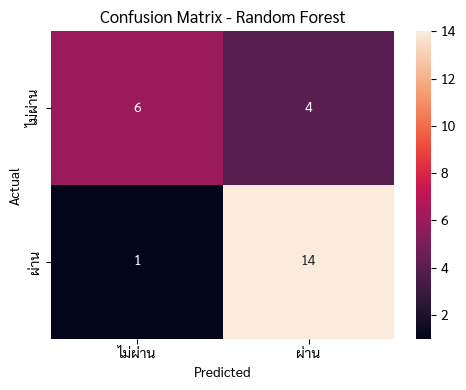


 Descion Tree :



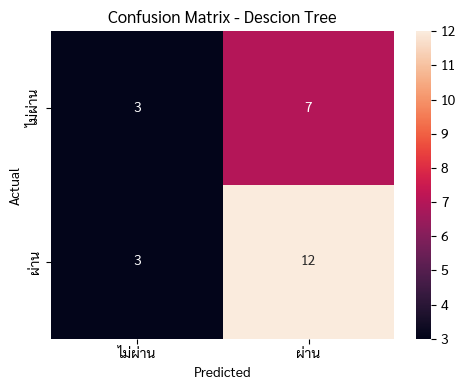

In [55]:
for name, model in ClassificationModels.items():
    # Add your code here
    print('\n', name, ':\n')

    pred_test = model.predict(X_test)
    cm = confusion_matrix(y_test, pred_test, labels=model.classes_)

    plt.figure(figsize=(5, 4))

    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=['ไม่ผ่าน', 'ผ่าน'],
                yticklabels=['ไม่ผ่าน', 'ผ่าน'])
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

## 4. Visualization of Error Metrics

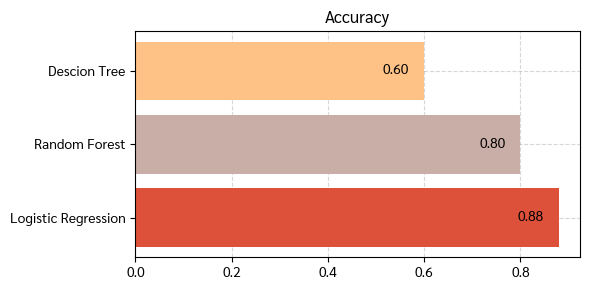

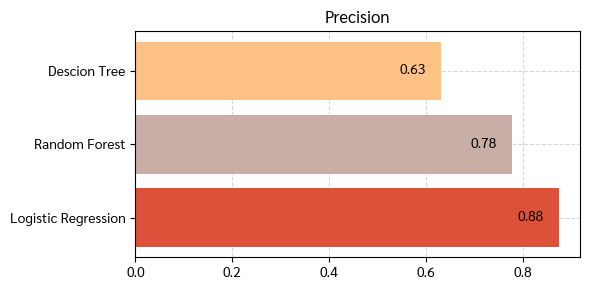

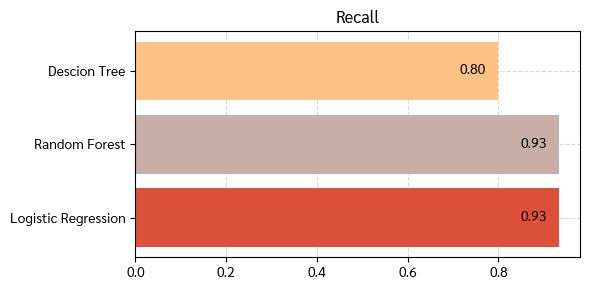

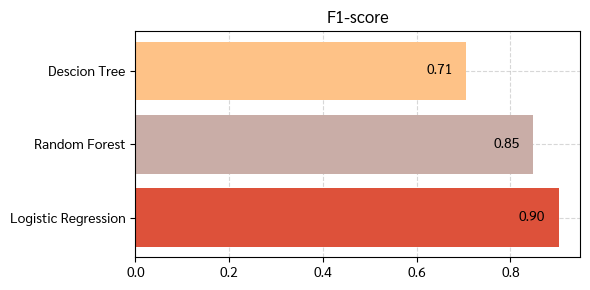

In [56]:
models_name = models_evaluate.index
metrics_name = models_evaluate.columns
for metric in models_evaluate:
    fig, ax = plt.subplots(figsize=(6, 3))

    values = models_evaluate[metric]
    bars = ax.barh(models_name, values, color=['#dd513a', '#c9ada7', '#fec287'])

    # Grid to the back
    ax.set_axisbelow(True)
    ax.grid(True, linestyle='--', alpha=0.5)

    # Title
    ax.set_title(metric)

    # Value labels (annotations)
    for bar in bars:
        width = bar.get_width()
        ax.annotate(f'{width:.2f}', xy=(width-0.1, bar.get_y() + bar.get_height() / 2),
                    xytext=(5, 0), textcoords="offset points",
                    ha='left', va='center')

    plt.tight_layout()
    plt.show()

    print('\n')

---
# BONUS: Multi-class Classification

**ใช้ข้อมูลชุดเดิม** : เปลี่ยน label จาก 2 ระดับเป็น 3 ระดับ

**แบ่งคุณภาพน้ำเป็น 3 ระดับ**

| ระดับ | เกณฑ์ WQI | ความหมาย |
|-------|-----------|----------|
| ดี | ≥ 71 | คุณภาพน้ำดี |
| พอใช้ | 61–70 | ใช้ได้แต่ต้องระวัง |
| เสื่อมโทรม | ≤ 60 | ต้องปรับปรุง |

In [57]:
# ใช้คอลัมน์ target_multi เป็น y ใหม่
y_multi = wqi['target_multi']
y_multi.value_counts()

,count
target_multi,
พอใช้,40
เสื่อมโทรม,33
ดี,25


In [58]:
# แบ่งข้อมูลฝึกและข้อมูลทดสอบ
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X, y_multi, test_size=0.25, random_state=42
)

In [59]:
# model
clf_m = LogisticRegression(random_state=42)
clf_m.fit(X_train_m, y_train_m)

LogisticRegression(random_state=42)

In [60]:
clf_m.classes_

array(['ดี', 'พอใช้', 'เสื่อมโทรม'], dtype=object)

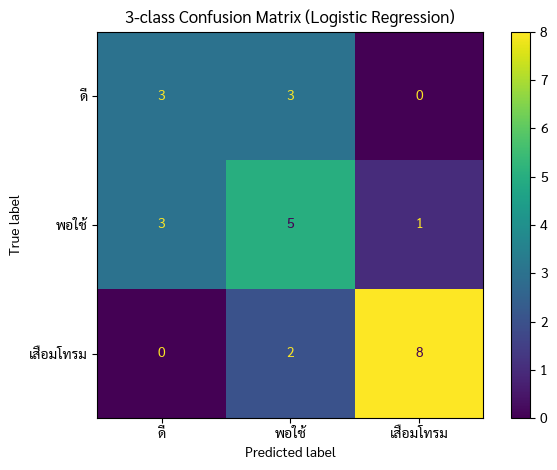

In [61]:
# ทำนาย + แสดง 3x3 Confusion Matrix
y_pred_m = clf_m.predict(X_test_m)

labels = ['ดี', 'พอใช้', 'เสื่อมโทรม']
cm_m = confusion_matrix(y_test_m, y_pred_m, labels=labels)
ConfusionMatrixDisplay(cm_m, display_labels=labels).plot()
plt.title('3-class Confusion Matrix (Logistic Regression)')
plt.tight_layout()
plt.show()